Nama : Felice Yang   
NIM : 2802406456   
Link Video : https://drive.google.com/drive/folders/1Zj9EUiU6mIl3f32sXJ5nREqrZFfsRFL7?usp=sharing

## Import Libraries

In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import classification_report, accuracy_score, f1_score, recall_score, precision_score

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.model_selection import cross_val_score

## Load Dataset

In [148]:
df = pd.read_csv("B.csv")
df.head()

,student_id,gender,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,extracurricular_activities,placement_status,salary_package_lpa
0,1,Male,53,79,56,8.87,50,92,90,1,3,23,4,91,4,Yes,0,0.00
1,2,Female,56,54,59,6.78,61,51,99,1,0,6,5,87,3,No,0,0.00
2,3,Male,94,83,83,7.92,91,93,84,1,1,10,2,81,2,No,1,6.92
3,4,Male,84,71,87,6.57,85,60,72,4,2,14,5,87,3,No,0,0.00
4,5,Male,58,88,74,9.01,73,52,88,1,2,20,0,60,1,No,0,0.00


## Data Understanding and Preprocessing

### Columns in Dataset

In [149]:
df.columns

Index(['student_id', 'gender', 'ssc_percentage', 'hsc_percentage',
       'degree_percentage', 'cgpa', 'entrance_exam_score',
       'technical_skill_score', 'soft_skill_score', 'internship_count',
       'live_projects', 'work_experience_months', 'certifications',
       'attendance_percentage', 'backlogs', 'extracurricular_activities',
       'placement_status', 'salary_package_lpa'],
      dtype='object')

### Check Data Dimension and Data Types

In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  5000 non-null   int64  
 1   gender                      5000 non-null   object 
 2   ssc_percentage              5000 non-null   int64  
 3   hsc_percentage              5000 non-null   int64  
 4   degree_percentage           5000 non-null   int64  
 5   cgpa                        5000 non-null   float64
 6   entrance_exam_score         5000 non-null   int64  
 7   technical_skill_score       5000 non-null   int64  
 8   soft_skill_score            5000 non-null   int64  
 9   internship_count            5000 non-null   int64  
 10  live_projects               5000 non-null   int64  
 11  work_experience_months      5000 non-null   int64  
 12  certifications              5000 non-null   int64  
 13  attendance_percentage       5000 

- Dataset terdiri dari **5000 baris dan 18 kolom (sebagian besar kolom mengandung tipe data numerik)**.
- **Tidak ada kesalahan tipe data**

### Check Duplicate

In [151]:
print("Duplicated Row : " ,df.duplicated().sum())

Duplicated Row :  0


**Tidak ada data duplikat.**

### Check Inconsistent

In [152]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols :
  print("Total Unique Values : ", df[col].nunique())
  print(df[col].value_counts())
  print()

Total Unique Values :  2
gender
Male      2504
Female    2496
Name: count, dtype: int64

Total Unique Values :  2
extracurricular_activities
No     2553
Yes    2447
Name: count, dtype: int64



- **Tidak ada data inkonsisten**
- **Distribusi pada gender dan extracurricular_activities relatif seimbang**

### Check Invalid Values

In [153]:
df.describe()

,student_id,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,placement_status,salary_package_lpa
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,2500.500000,72.425800,71.910800,71.845200,7.678326,69.197800,69.651000,69.839600,1.987800,2.491800,11.982000,2.481000,79.433400,2.518400,0.173200,1.59589
std,1443.520003,13.199642,12.842781,10.013196,1.237084,17.325528,17.179704,17.170732,1.410975,1.704967,7.258114,1.719485,11.638585,1.721004,0.378458,3.77582
min,1.000000,50.000000,50.000000,55.000000,5.500000,40.000000,40.000000,40.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,0.000000,0.00000
25%,1250.750000,61.000000,61.000000,63.000000,6.617500,54.000000,55.000000,55.000000,1.000000,1.000000,6.000000,1.000000,69.000000,1.000000,0.000000,0.00000
50%,2500.500000,72.000000,72.000000,72.000000,7.700000,69.000000,70.000000,69.000000,2.000000,3.000000,12.000000,2.000000,80.000000,3.000000,0.000000,0.00000
75%,3750.250000,84.000000,83.000000,80.000000,8.750000,84.000000,84.000000,85.000000,3.000000,4.000000,18.000000,4.000000,89.000000,4.000000,0.000000,0.00000
max,5000.000000,95.000000,94.000000,89.000000,9.800000,99.000000,99.000000,99.000000,4.000000,5.000000,24.000000,5.000000,99.000000,5.000000,1.000000,14.99000


- Semua nilai numerik masih realistis dan berada dalam batas logis sehingga **tidak ada fitur yang mengandung invalid values**.
- Mean placement_status = 0.173 yang berarti hanya 17% yang placement
- Median dan Q3 dari salary = 0 yang berarti mayoritas masih belum bekerja.

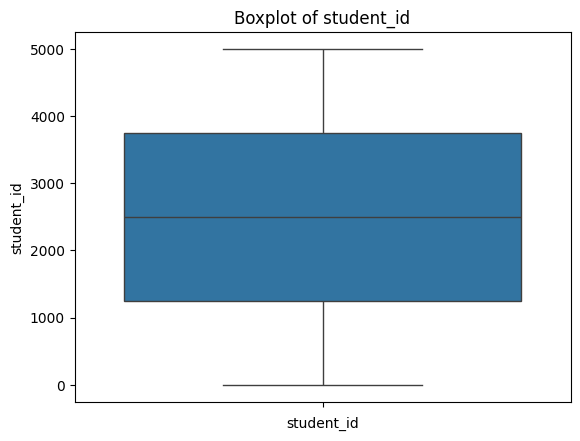

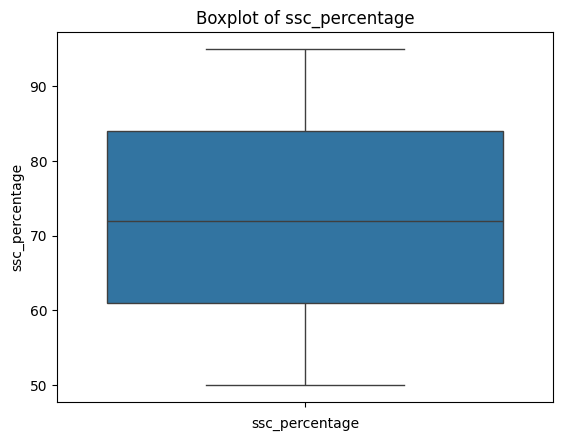

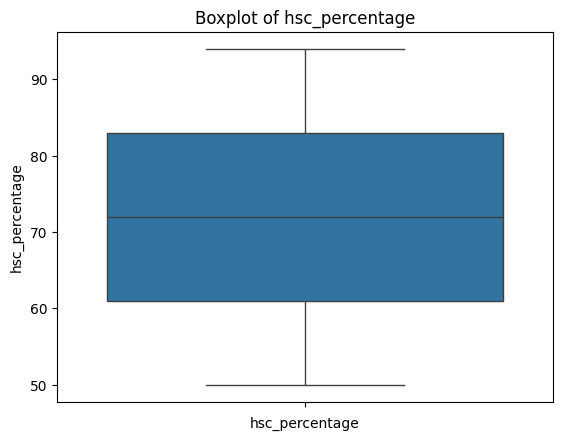

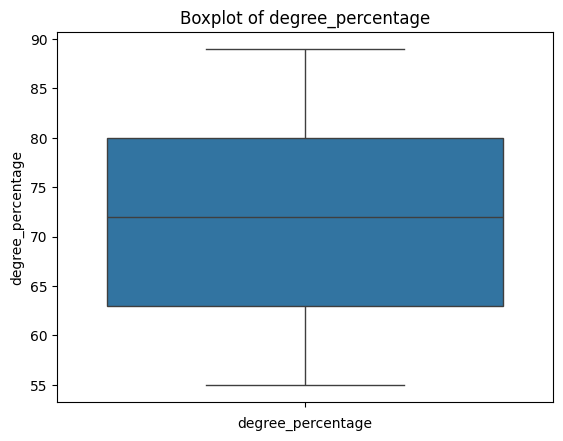

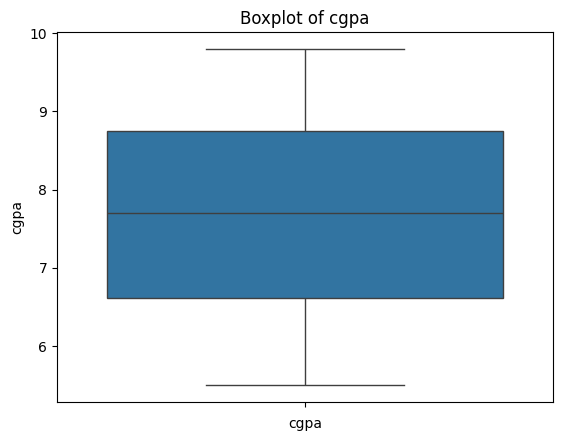

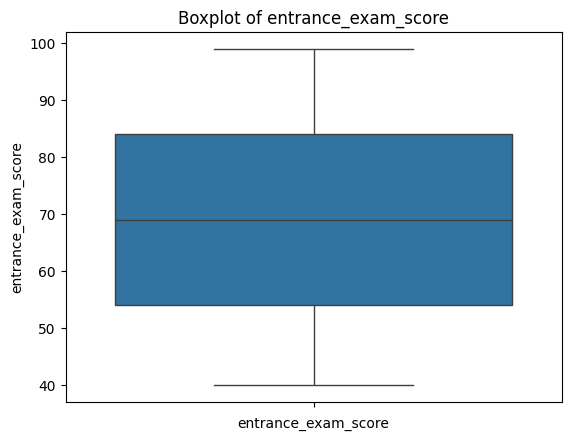

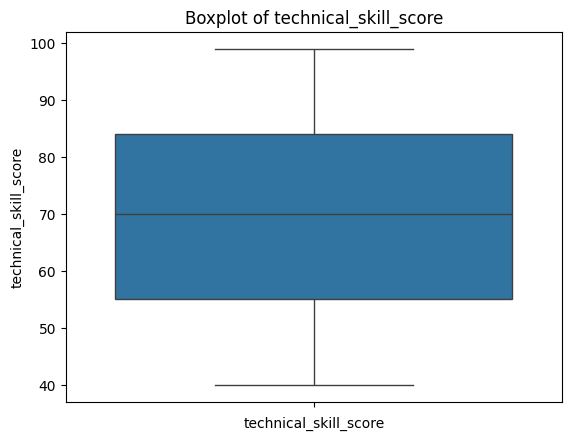

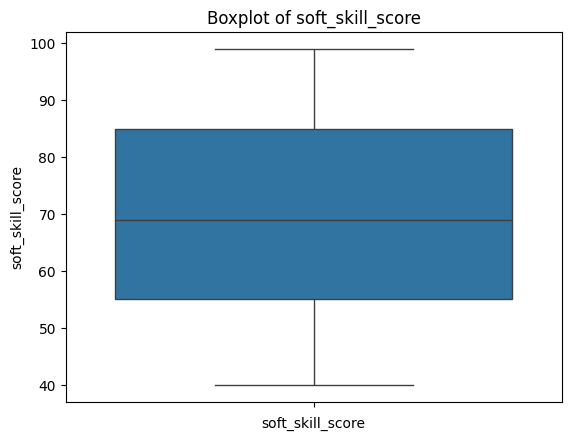

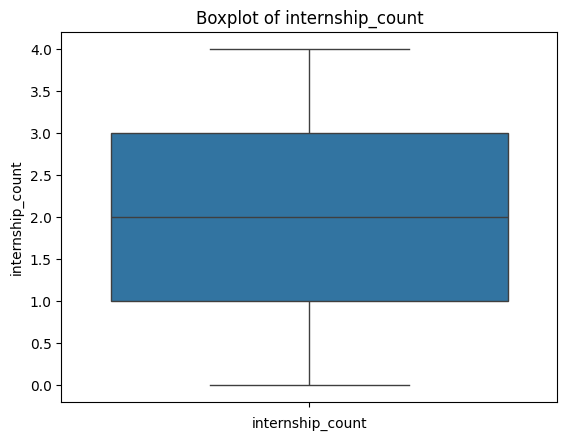

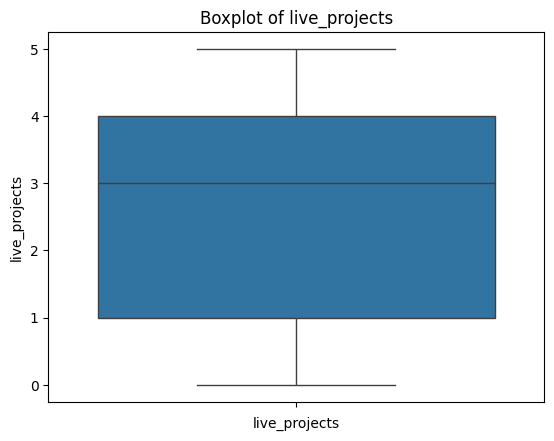

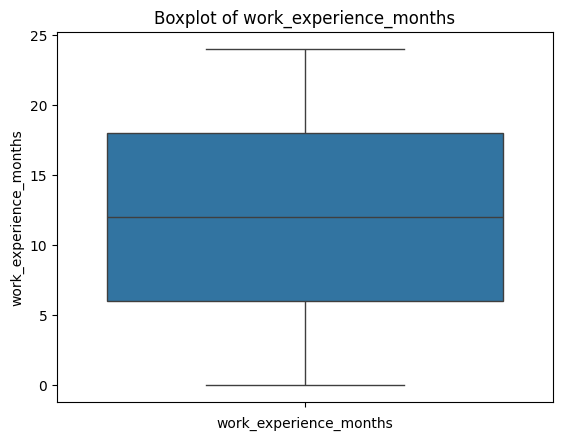

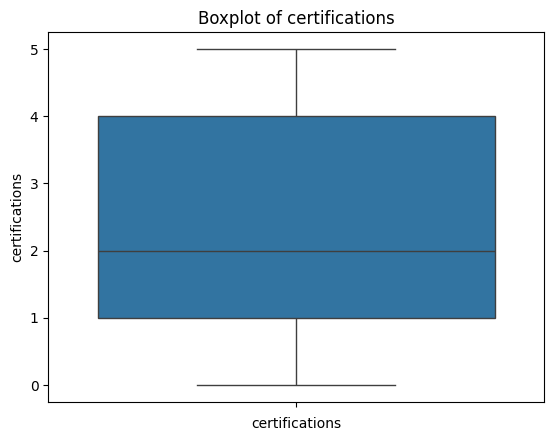

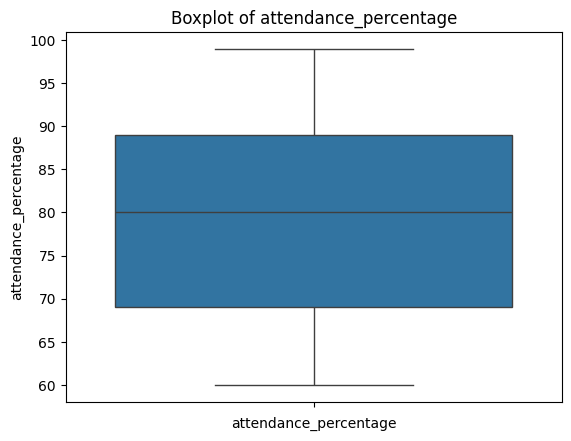

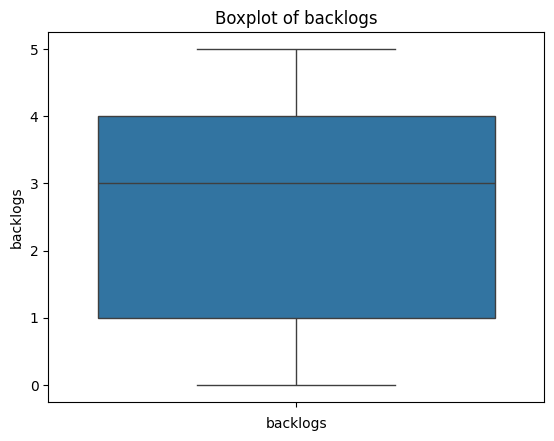

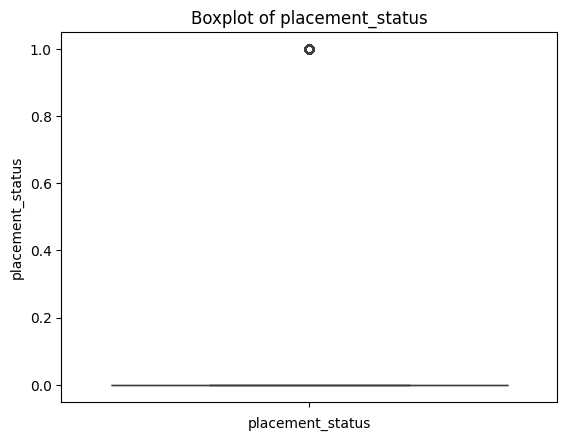

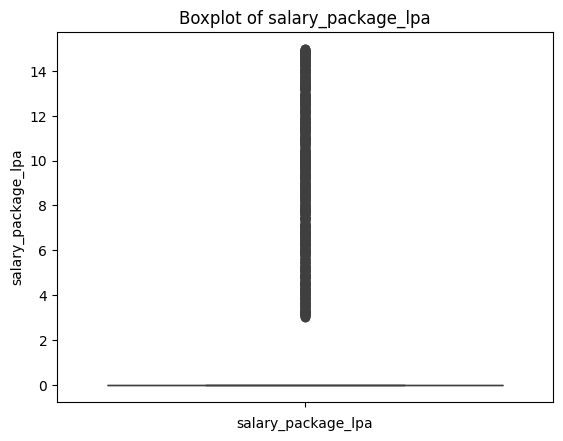

In [154]:
num_cols = df.select_dtypes(exclude=['object']).columns

for col in num_cols :
  sns.boxplot(y = df[col])
  plt.title(f'Boxplot of {col}')
  plt.xlabel(col)
  plt.show()

- Secara umum, mahasiswa terlihat memiliki performa akademik dan skill yang cukup baik
- Jumlah backlog yang relatif tinggi dapat mempengaruhi peluang placement. (rata rata ~2.5 dan median = 3)
- Distribusi salary tidak merata, dengan mayoritas bernilai 0 karena banyak yang belum bekerja

### Check Missing Values

In [155]:
df.isnull().sum()

student_id                    0
gender                        0
ssc_percentage                0
hsc_percentage                0
degree_percentage             0
cgpa                          0
entrance_exam_score           0
technical_skill_score         0
soft_skill_score              0
internship_count              0
live_projects                 0
work_experience_months        0
certifications                0
attendance_percentage         0
backlogs                      0
extracurricular_activities    0
placement_status              0
salary_package_lpa            0
dtype: int64

**Tidak ada missing value.**

### Handling Meaningless Features

In [156]:
df = df.drop(columns=['student_id'])

### Check Target Distribution

In [157]:
df['placement_status'].value_counts(normalize=True)

placement_status
0    0.8268
1    0.1732
Name: proportion, dtype: float64

Terdapat masalah **Imbalanced Data**. Class 0 (tidak mendapatkan placement) jauh lebih banyak dibandingkan Class 1 (mendapatkan placement).

## EDA

### Distribution

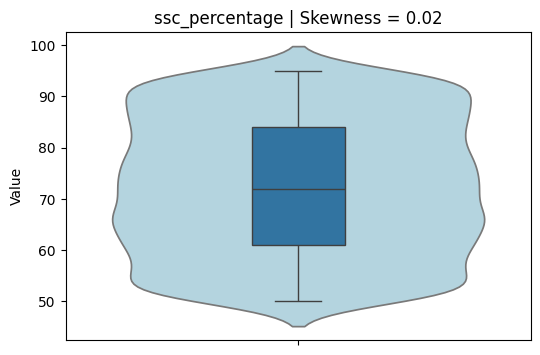

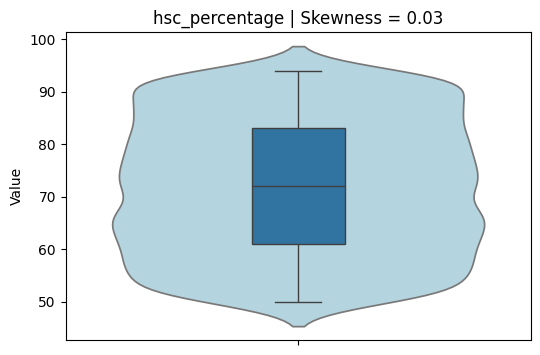

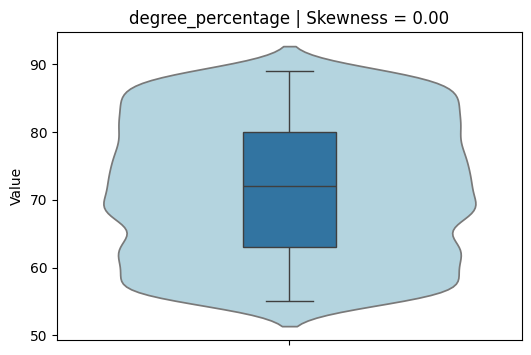

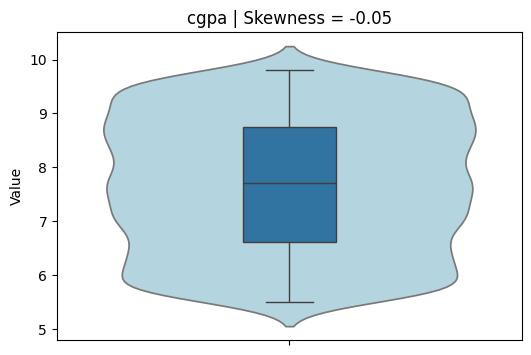

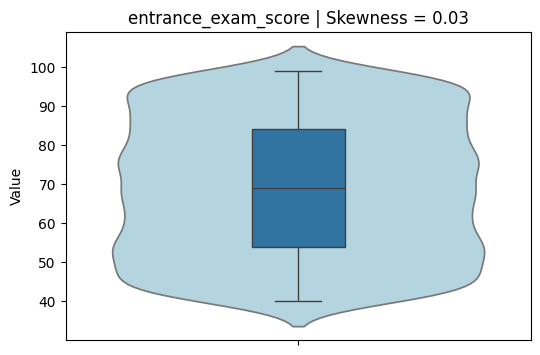

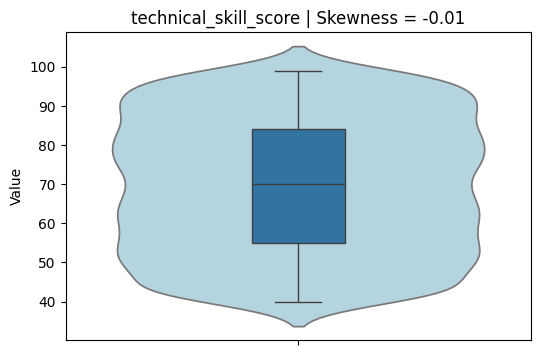

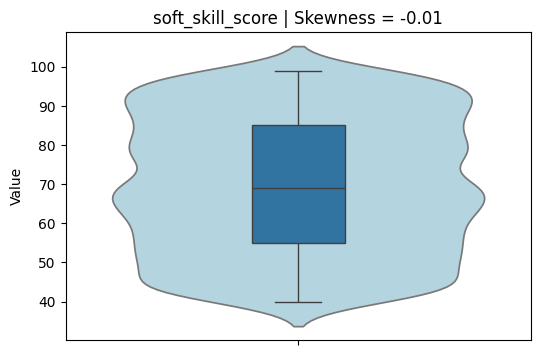

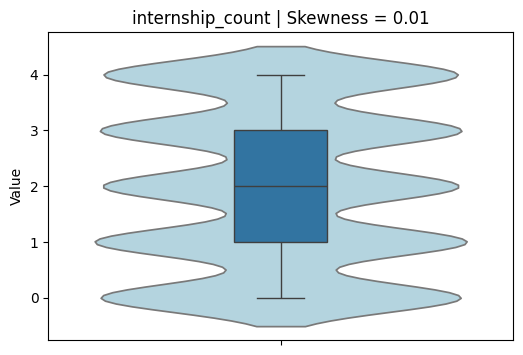

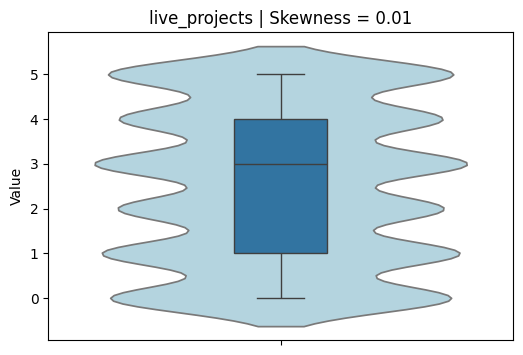

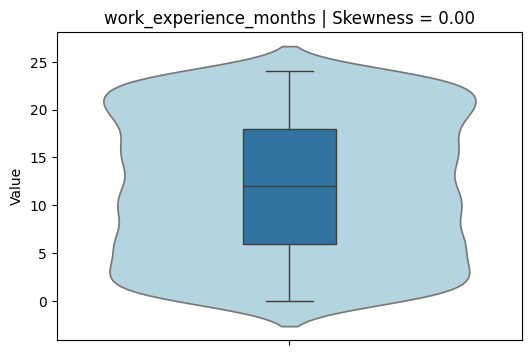

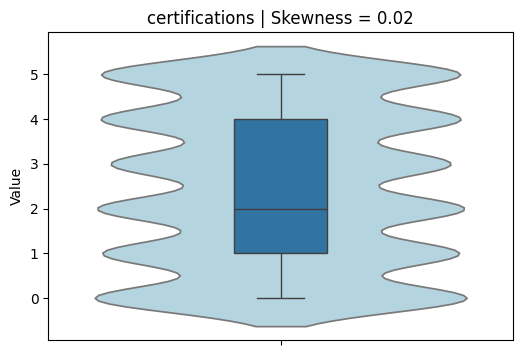

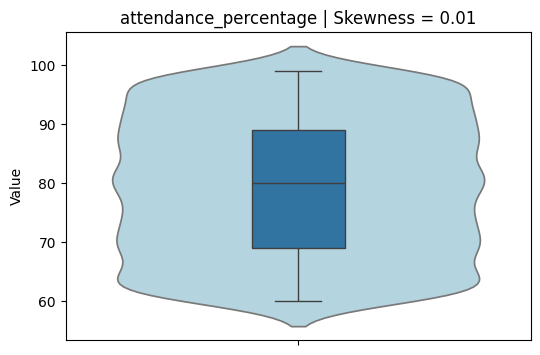

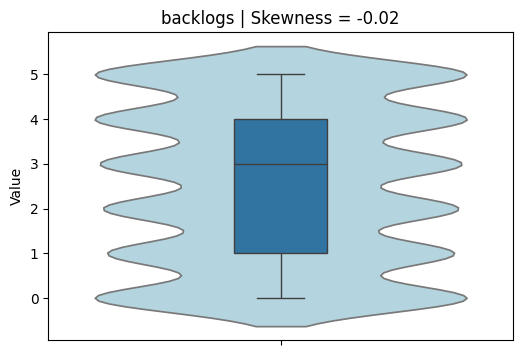

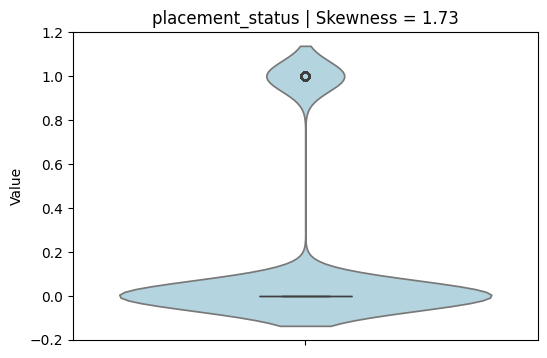

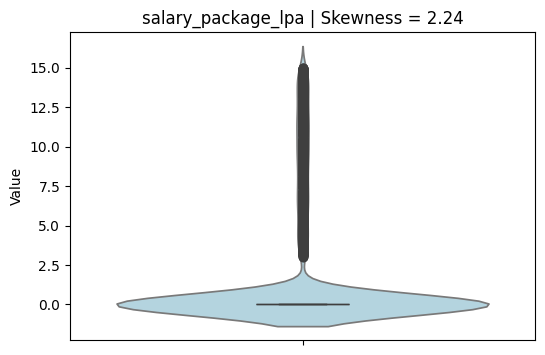

In [158]:
num_cols = df.select_dtypes(exclude=['object']).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.violinplot(y=df[col], inner=None, color="lightblue")
    sns.boxplot(y=df[col], width=0.2)
    plt.title(f"{col} | Skewness = {df[col].skew():.2f}")
    plt.ylabel("Value")
    plt.show()

Sebagian besar variabel numerik memiliki **distribusi yang cukup simetris dan tidak menunjukkan adanya outlier ekstrem yang signifikan**.
Namun, **variabel salary_package_lpa memiliki distribusi yang sangat condong ke kanan (right-skewed)**, dengan banyak nilai nol. Hal ini menunjukkan bahwa sebagian besar mahasiswa belum mendapatkan pekerjaan.

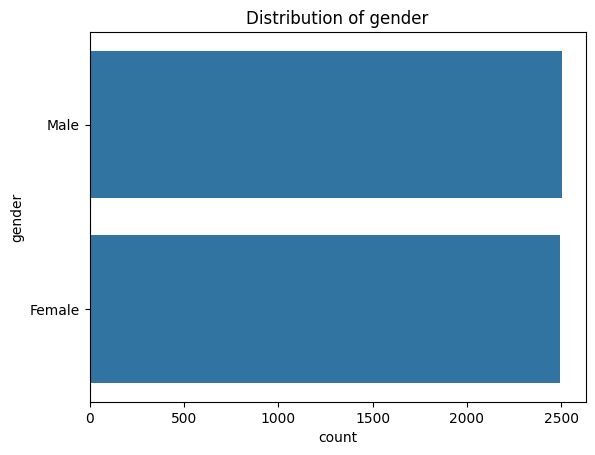

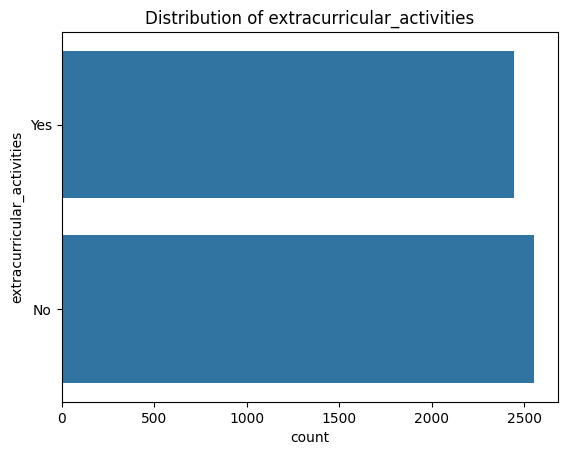

In [159]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    sns.countplot(data=df, y=col)
    plt.title(f'Distribution of {col}')
    plt.show()

**Distribusi variabel kategorikal seimbang**, baik pada gender maupun partisipasi kegiatan ekstrakurikuler

### Correlation

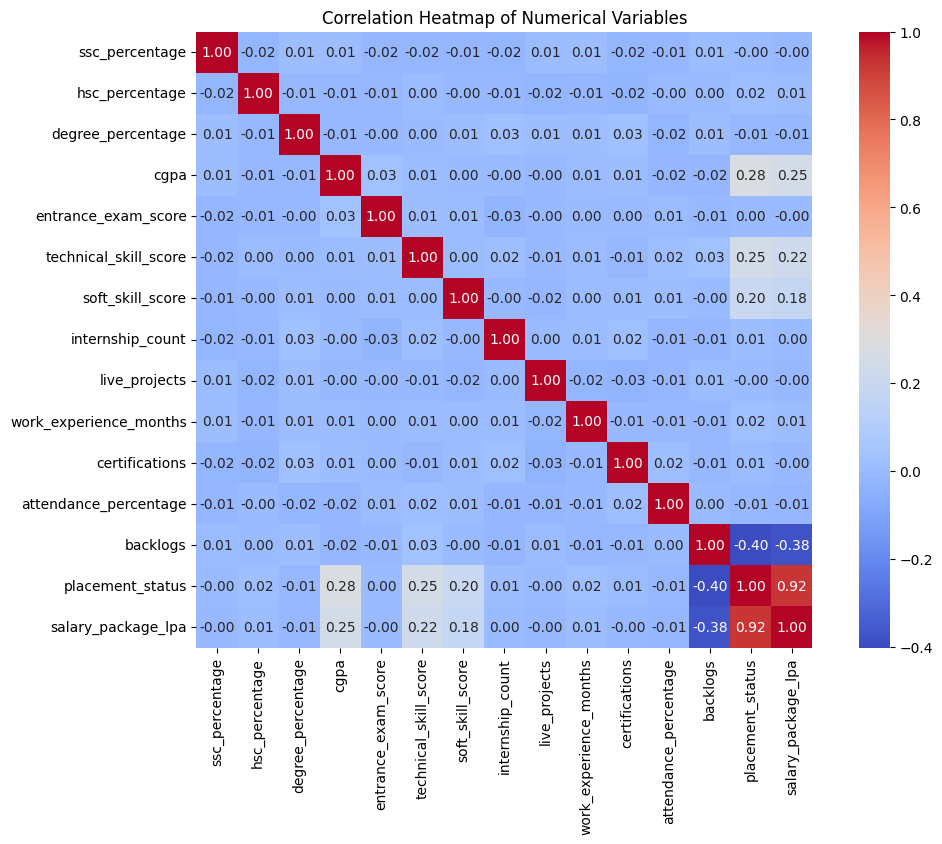

In [160]:
num_cols = df.select_dtypes(exclude=['object'])

corr_matrix = num_cols.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot = True, fmt = ".2f", cmap = "coolwarm", square=True)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

- **placement_status** memiliki **korelasi positif** dengan variabel **cgpa, technical_skill_score, dan soft_skill_score** -> menunjukkan performa akademik dan keterampilan berkontribusi terhadap peluang mendapatkan pekerjaan.
- **backlogs** memiliki **korelasi negatif** terhadap **placement_status** -> semakin banyak backlog, semakin kecil kemungkinan mahasiswa mendapatkan pekerjaan.
- **salary_package_lpa** memiliki **korelasi yang sangat tinggi** dengan **placement_status** -> adanya potensi data leakage jika kedua variabel digunakan bersamaan dalam model.

In [161]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

cat_cols = df.select_dtypes(include=["object"]).columns

cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

cramers_matrix = cramers_matrix.astype(float)

print("Cramer's V antar variabel kategorikal:")
cramers_matrix.round(3)

Cramer's V antar variabel kategorikal:


,gender,extracurricular_activities
gender,1.000,0.022
extracurricular_activities,0.022,1.000


Nilai Cramer’s V sebesar 0.022 menunjukkan bahwa hubungan antara variabel gender dan extracurricular_activities sangat lemah (mendekati 0). Hal ini berarti kedua variabel bersifat independen dan tidak saling mempengaruhi.

In [162]:
target = "placement_status"

cramer_results = {}

for col in cat_cols:
    cramer_results[col] = cramers_v(df[col], df[target])

cramer_df = pd.DataFrame.from_dict(cramer_results, orient="index", columns=["Cramers_V"])

print("Cramer's V antara variabel kategorikal dan placement_status:")
cramer_df.sort_values("Cramers_V", ascending=False).round(3)

Cramer's V antara variabel kategorikal dan placement_status:


,Cramers_V
extracurricular_activities,0.017
gender,0.007


Nilai Cramer’s V untuk kedua variabel sangat rendah (< 0.05), yang menunjukkan gender dan extracurricular_activities memiliki hubungan yang sangat lemah terhadap placement_status.

In [163]:
for col in cat_cols:
    print(f"\nRata-rata salary berdasarkan {col}:")
    print(df.groupby(col)['salary_package_lpa'].mean())


Rata-rata salary berdasarkan gender:
gender
Female    1.556595
Male      1.635060
Name: salary_package_lpa, dtype: float64

Rata-rata salary berdasarkan extracurricular_activities:
extracurricular_activities
No     1.634078
Yes    1.556048
Name: salary_package_lpa, dtype: float64


Rata-rata salary antar kategori menunjukkan perbedaan yang sangat kecil (tidak signifikan)

## Feature Engineering

In [164]:
df['total_skills'] = df['technical_skill_score'] + df['soft_skill_score']
df['experience_score'] = df['internship_count'] + df['work_experience_months']/12

**Pembuatan fitur baru dilakukan untuk meningkatkan kemampuan model dalam menangkap data** (menyederhanakan informasi kompleks) **dan merepresentasikan kemampuan mahasiswa** secara lebih komprehensif.
- **total skills = technical skill + soft skill** -> memberikan **representasi yang lebih menyeluruh** terhadap kemampuan mahasiswa.
- **experience score = internship count + work experience (dalam tahun)** -> **mengkombinasikan mengalaman internship dan pengalaman kerja menjadi satu metrik** yang lebih informatif.

## Splitting Data

In [165]:
x = df.drop(columns=['placement_status', 'salary_package_lpa'])
y_cls = df['placement_status']

x_train_cls, x_test_cls, y_train_cls, y_test_cls = train_test_split(
    x, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

In [166]:
df_reg = df[df['placement_status'] == 1]
x_reg = df_reg.drop(columns=['placement_status', 'salary_package_lpa'])
y_reg = df_reg['salary_package_lpa']

x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(
    x_reg, y_reg, test_size=0.2, random_state=42)

Dataset dibagi menjadi **80% training dan 20% testing**.    
stratify digunakan untuk menjaga distribusi kelas tetap seimbang karena data imbalance

Dilakukan **two-stage modeling**, dimana : 
1. **model klasifikasi untuk memprediksi status placement** dan 
2. model **regresi digunakan untuk data dengan placement_status = 1**   

Salary bernilai 0 untuk mahasiswa yang tidak mendapatkan pekerjaan, sehingga:
- Jika seluruh data digunakan → model bias ke nilai 0
- Dengan filtering → model fokus pada prediksi salary yang valid

In [167]:
num_cols = x.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = x.select_dtypes(include=['object']).columns.tolist()

## Preprocessing Pipeline

### Numerical Pipeline

In [168]:
num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')),
                         ('scaler', StandardScaler())])

### Categorical Pipeline

In [169]:
cat_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                         ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))])

### Penggabungan

In [170]:
preprocessor = ColumnTransformer([('num', num_pipeline, num_cols),
                                  ('cat', cat_pipeline, cat_cols)])

Preprocessing dilakukan menggunakan pipeline untuk menghindari data leakage dan memastikan konsistensi saat deployment.
- **Numerical : missing value -> imputasi median, scaling -> standard scaler**
- **Categorical : missing value ->  imputasi modus, encoding ->  one hot encoder**

## Modeling

### Classification

In [171]:
scale_pos_weight = (y_train_cls == 0).sum() / (y_train_cls == 1).sum()

models_cls = {
    "logistic_regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "random_forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "gradient_boosting": GradientBoostingClassifier(random_state=42),
    "xgboost": XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=42
    ),
    "knn": KNeighborsClassifier()
}

Untuk handling imbalance, digunakan class_weight pada Logistic dan Random Forest, serta scale_post_weight pada XGBoost

In [172]:
results_cls = []

for name, model in models_cls.items():
    pipeline = Pipeline([('preprocessing', preprocessor),
                         ('model', model)])
    
    pipeline.fit(x_train_cls, y_train_cls)
    
    y_pred = pipeline.predict(x_test_cls)
    
    acc = accuracy_score(y_test_cls, y_pred)
    f1 = f1_score(y_test_cls, y_pred)
    recall = recall_score(y_test_cls, y_pred)
    precision = precision_score(y_test_cls, y_pred)
    
    print(f"\n===== {name} =====")
    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-Score:", f1)
    print(classification_report(y_test_cls, y_pred))
    
    results_cls.append({"model": name,
                        "accuracy": acc,
                        "f1_score": f1,
                        "recall": recall})


===== logistic_regression =====
Accuracy: 0.84
Precision: 0.5221843003412969
Recall: 0.884393063583815
F1-Score: 0.6566523605150215
              precision    recall  f1-score   support

           0       0.97      0.83      0.90       827
           1       0.52      0.88      0.66       173

    accuracy                           0.84      1000
   macro avg       0.75      0.86      0.78      1000
weighted avg       0.89      0.84      0.85      1000


===== random_forest =====
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       827
           1       1.00      1.00      1.00       173

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


===== gradient_boosting =====
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
              precision    recall  f1-score  

#### Cross Validation

In [173]:
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42))])

scores = cross_val_score(pipeline, x, y_cls, cv=5, scoring='f1')

print("CV F1-score:", scores)
print("Mean:", scores.mean())

CV F1-score: [1.         0.99710145 0.99710145 0.99418605 0.99711816]
Mean: 0.9971014201363898


Mean F1 = 0.997 -> konsisten tinggi di semua fold.   
Artinya model benar-benar belajar pola bukan hafalan data.

#### Shuffle Test

In [174]:
y_random = np.random.permutation(y_cls)

pipeline.fit(x_train_cls, y_random[:len(y_train_cls)])
y_pred = pipeline.predict(x_test_cls)

print("F1 random:", f1_score(y_test_cls, y_pred))

F1 random: 0.0


Model tidak bisa belajar kalau target diacak -> tidak ada kebocoran fitur (leakage)

- Model tree-based (**Random Forest, Gradient Boosting, dan XGBoost**) mencapai **performa hampir sempurna (bernilai = 1.0**). 
- Logistic Regression dan KNN memiliki performa yang lebih seimbang.
- Performa tinggi ini menunjukkan bahwa fitur dalam dataset sangat informatif dan memiliki hubungan kuat dengan target.
- Setelah dilakukan **validasi tambahan (cross-validation dan shuffle test)** dapat disimpulkan **tidak adanya data leakage, model benar-benar belajar dari pola data**.

### Regression

In [175]:
models_reg = {
    "linear_regression": LinearRegression(),
    "random_forest": RandomForestRegressor(random_state=42),
    "gradient_boosting": GradientBoostingRegressor(random_state=42),
    "xgboost": XGBRegressor(random_state=42),
    "svr": SVR()
}

In [176]:
results_reg = []

for name, model in models_reg.items():
    pipeline = Pipeline([('preprocessing', preprocessor),
                         ('model', model)])
    
    pipeline.fit(x_train_reg, y_train_reg)
    
    y_pred = pipeline.predict(x_test_reg)
    
    mae = mean_absolute_error(y_test_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    r2 = r2_score(y_test_reg, y_pred)
    
    print(f"\n===== {name} =====")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)
    
    results_reg.append({"model": name,
                        "mae": mae,
                        "rmse": rmse,
                        "r2": r2})


===== linear_regression =====
MAE: 2.9964441202852794
RMSE: 3.451607182790836
R2: 0.024774204842168746

===== random_forest =====
MAE: 3.139832758620689
RMSE: 3.6041064738711595
R2: -0.06330456169291243

===== gradient_boosting =====
MAE: 3.094871338235195
RMSE: 3.600034622471841
R2: -0.060903316092428605

===== xgboost =====
MAE: 3.332642074891891
RMSE: 3.895525082911977
R2: -0.24220840097615337

===== svr =====
MAE: 3.0425736238755117
RMSE: 3.5243570186260818
R2: -0.016768877151007944


- **Linear Regression memiliki performa terbaik** dibandingkan dengan model lain.
- **Prediksi salary sulit dilakukan karena variasi data yang tinggi dan jumlah data yang lebih sedikit setelah filtering**. Meskipun performa rendah, pendekatan ini lebih valid dibanding menggunakan seluruh data yang bias terhadap nilai 0.

In [177]:
results_cls_df = pd.DataFrame(results_cls).sort_values(by="f1_score", ascending=False)
results_reg_df = pd.DataFrame(results_reg).sort_values(by="r2", ascending=False)

print("\n===== Classification =====")
print(results_cls_df)

print("\n===== Regression =====")
print(results_reg_df)


===== Classification =====
                 model  accuracy  f1_score    recall
1        random_forest     1.000  1.000000  1.000000
2    gradient_boosting     1.000  1.000000  1.000000
3              xgboost     1.000  1.000000  1.000000
4                  knn     0.906  0.708075  0.658960
0  logistic_regression     0.840  0.656652  0.884393

===== Regression =====
               model       mae      rmse        r2
0  linear_regression  2.996444  3.451607  0.024774
4                svr  3.042574  3.524357 -0.016769
2  gradient_boosting  3.094871  3.600035 -0.060903
1      random_forest  3.139833  3.604106 -0.063305
3            xgboost  3.332642  3.895525 -0.242208


**Final model** : 
- **Classification -> Random Forest** (lebih stabil untuk generalisasi, praktis, dan efisien)
- **Regression -> Linear Regression** (baseline terbaik)